# 16. Ranking fifteen candidate families

::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

`Distribution.fit()` answers "what are the parameters of this family". `fit_distributions()` answers
the question that comes before it: which family. It fits every candidate in the RMC.BestFit
`DistributionList` to the same sample by maximum likelihood and reports AIC, BIC and RMSE for each,
leaving the ranking to you. There are fifteen candidates, and this page is about reading their
table honestly on a record short enough that the ranking is not settled.

Example 02 uses `fit_distributions()` in passing, at the end of a page about estimation methods.
This one is about the verb itself. It has no upstream counterpart: the USACE-RMC
Numerics-Python-Examples repository has no distribution-selection notebook.

## What you'll learn

- What the fifteen candidates are, and which of them can fail on a given sample.
- Why AIC, BIC and RMSE can each name a different winner, and what to do about that.
- How to read the `converged` column, which is not a warning to ignore.
- How to get the parameters of the family you picked, which the ranking does not carry.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corehydropy as ch

## The record

Twenty annual peak discharges, the same series the package's own oracle fixture uses, so the
numbers below are pinned against the real C# `FittingAnalysis` at the bottom of this page.

In [2]:
peaks = [45000, 38000, 52000, 61000, 33000, 49000, 55000, 42000, 67000, 39000,
         48000, 51000, 36000, 58000, 44000, 53000, 47000, 62000, 41000, 50000]

print(f"n = {len(peaks)}, mean = {np.mean(peaks):.0f} cfs, "
      f"range = {min(peaks):.0f} to {max(peaks):.0f} cfs")

n = 20, mean = 48550 cfs, range = 33000 to 67000 cfs


Twenty years is a short record, and the point of this page is that the ranking says so.

## The ranking

One call. The result is a dict of five parallel lists, one entry per candidate, which
`pd.DataFrame` turns into a table.

In [3]:
ranking = pd.DataFrame(ch.fit_distributions(peaks))
ranking["dAIC"] = ranking["aic"] - ranking["aic"].min()

ranking.sort_values("aic")[["distribution", "aic", "dAIC", "bic", "rmse", "converged"]] \
    .reset_index(drop=True)

,distribution,aic,dAIC,bic,rmse,converged
0,GeneralizedPareto,423.311917,0.000000,426.299114,1278.642551,True
1,GammaDistribution,424.152932,0.841015,426.144397,1335.938994,True
2,LogNormal,424.227842,0.915925,426.219306,1302.785782,True
3,LnNormal,424.227842,0.915925,426.219307,1302.403434,True
4,Normal,424.519270,1.207353,426.510734,1436.096862,True
5,Gumbel,425.013211,1.701294,427.004676,1205.713399,True
6,Weibull,425.482306,2.170389,427.473770,1464.274929,True
7,Logistic,425.540285,2.228368,427.531749,1442.125566,True
8,GeneralizedExtremeValue,425.940702,2.628785,428.927899,1388.563194,True
9,PearsonTypeIII,426.120582,2.808665,429.107779,1303.292411,True


Fifteen rows, one per candidate. `converged` is `False` for KappaFour, whose four-parameter fit did
not converge on this sample; its metrics are `NaN` and it cannot be ranked. A failed candidate is
not a defect in the sample or in the fit. It is the honest report that this family had nothing to
say about this record, and its row is kept rather than dropped so
that a candidate cannot disappear from the list without being noticed.

## Three criteria, three winners

Sorting the same table by each of the three metrics gives three different leaders.

In [4]:
def leader(metric):
    ok = ranking.dropna(subset=[metric])
    return ok["distribution"][ok[metric].idxmin()]


print(f"lowest AIC:  {leader('aic')}")
print(f"lowest BIC:  {leader('bic')}")
print(f"lowest RMSE: {leader('rmse')}")

lowest AIC:  GeneralizedPareto
lowest BIC:  GammaDistribution
lowest RMSE: Gumbel


They disagree because they reward different things. AIC penalizes each parameter by 2, BIC by
$\ln n$, which is 3.0 at twenty points, so BIC is stiffer and demotes every three-parameter family
by about one point relative to AIC. RMSE is not a likelihood criterion at all: it measures the
distance between the fitted quantiles and the observations at their Hirsch-Stedinger plotting
positions, so it rewards a family that tracks the middle of the record even when the likelihood
prefers another.

The AIC column has the more useful reading. Twelve of the fourteen rankable candidates fall within
three AIC points of the best, and six of them within two, which on twenty observations is not
evidence of anything. The table's real message is that most of these families describe this record
about equally well, and that picking one of them by its rank alone is picking noise.

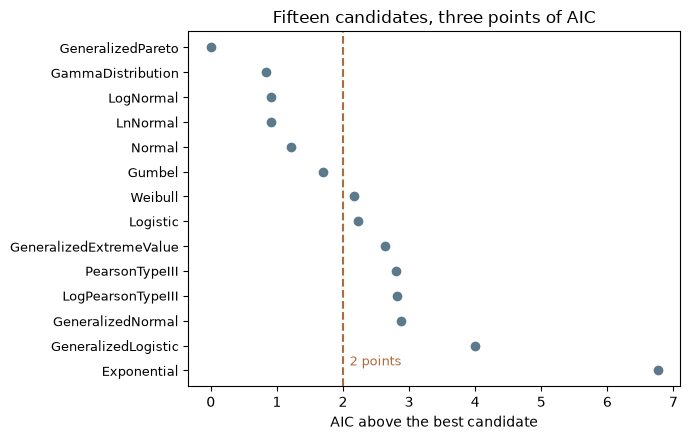

In [5]:
ranked = ranking.dropna(subset=["aic"]).sort_values("aic").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
y = np.arange(len(ranked))[::-1]
ax.plot(ranked["dAIC"], y, "o", color="#5b7a8c")
ax.axvline(2, color="#b06a3b", linestyle="--")
ax.text(2.1, 0.2, "2 points", color="#b06a3b", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(ranked["distribution"], fontsize=9)
ax.set_xlabel("AIC above the best candidate")
ax.set_title("Fifteen candidates, three points of AIC")
fig.tight_layout()
plt.show()

## The winner, and why to distrust it

`fit_distributions()` reports metrics, not parameters. Refit the family you picked with
`Distribution.fit()` to get them.

In [6]:
best = ch.Distribution.fit("GeneralizedPareto", peaks, method="mle")
print(best)

lower = best.params[0]
upper = best.params[0] + best.params[1] / best.params[2]
print(f"support: {lower:.0f} to {upper:.0f} cfs")
print(f"observed: {min(peaks):.0f} to {max(peaks):.0f} cfs")
print(f"quantile at p = 0.99999: {best.quantile(0.99999):.0f} cfs")

Distribution(GeneralizedPareto(ξ = 33000, α = 29295.7, κ = 0.852354))
support: 33000 to 67370 cfs
observed: 33000 to 67000 cfs
quantile at p = 0.99999: 67368 cfs


Look at what the AIC winner actually did. Its location parameter is 33,000, exactly the smallest
observation, and with a positive shape the family is bounded above as well, here at 67,370 cfs,
370 cfs past the largest observation. The fit has pulled its entire support onto the observed range.
It follows that this distribution assigns probability zero to any flood above 67,370 cfs: the
quantile at a one-in-100,000 exceedance is still 67,368.

Nothing in the table reports that. AIC rewards the likelihood, and a support squeezed onto the data
is where the likelihood is largest, so a bounded three-parameter family will often top a short
record. It is a property of twenty observations, not a finding about the river. Read `dAIC` rather
than the rank, look at the support of whatever wins, and prefer a family you can defend on physical
grounds when the table is this flat.

## The fifteenth candidate

`GeneralizedNormal` is the three-parameter LogNormal, called the generalized normal in Hosking's
L-moment work: location $\xi$, scale $\alpha$, shape $\kappa$. At $\kappa = 0$ it is the plain
Normal; $\kappa < 0$ bounds it below at $\xi + \alpha / \kappa$ and skews it right, and $\kappa > 0$
does the mirror image.

In [7]:
gn = ch.Distribution.fit("GeneralizedNormal", peaks, method="mle")
print(gn)
print(f"implied lower bound: {gn.params[0] + gn.params[1] / gn.params[2]:.0f} cfs")
print(f"100-year peak: {gn.quantile(0.99):.0f} cfs")

Distribution(GeneralizedNormal(ξ = 47929.3, α = 8829.03, κ = -0.140333))
implied lower bound: -14986 cfs
100-year peak: 72218 cfs


Its shape parameter is barely below zero, so the fitted density is nearly Normal and the implied
lower bound falls at about -15,000 cfs, far outside anything a river can do. That is the sensible
reading of a small $\kappa$: the bound is not a claim about discharge, it is the family telling you
it found no skew worth the third parameter. Which is why the row sits in the middle of the AIC
table. It spent a parameter to repeat what the Normal already said.

## The frequency curve

The three leading families, plotted against the record on its Weibull plotting positions. This is
the plot that shows what a three-point AIC spread means.

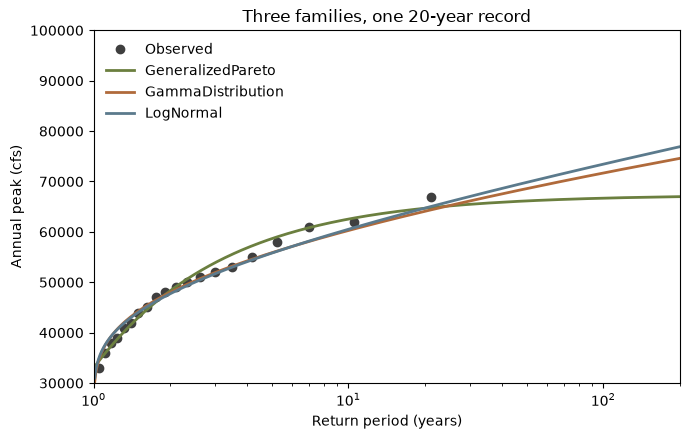

In [8]:
families = ["GeneralizedPareto", "GammaDistribution", "LogNormal"]
fits = [ch.Distribution.fit(f, peaks, method="mle") for f in families]
pp = ch.plotting_positions(len(peaks))
grid = np.linspace(0.01, 0.995, 300)
colors = ["#6b7f3f", "#b06a3b", "#5b7a8c"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(1 / (1 - pp), np.sort(peaks), "o", color="#3f3f3f", label="Observed")
for fit, family, color in zip(fits, families, colors):
    ax.semilogx(1 / (1 - grid), fit.quantile(grid), color=color, linewidth=2, label=family)
ax.set_xlim(1, 200)
ax.set_ylim(30000, 100000)
ax.set_xlabel("Return period (years)")
ax.set_ylabel("Annual peak (cfs)")
ax.set_title("Three families, one 20-year record")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

The three curves track each other over the range the data cover and part company past it, which is
exactly where a design estimate is read. The AIC winner is the one that flattens: its curve bends
into the ceiling described above, while the two families ranked below it keep rising. Ranking
settles which family fits the observations. It does not settle the extrapolation, and no table
built from twenty points can.

In [9]:
for family, fit in zip(families, fits):
    print(f"{family:>18}: {fit.quantile(0.99):.0f} cfs")

 GeneralizedPareto: 66692 cfs
 GammaDistribution: 71682 cfs
         LogNormal: 73440 cfs


## Key takeaways

1. `fit_distributions()` fits fifteen candidates and reports AIC, BIC and RMSE. Ranking is yours,
   and so is the decision not to trust the ranking.
2. AIC, BIC and RMSE reward different things and can each name a different winner. On a short
   record that disagreement is the finding.
3. `converged = False` means that candidate's MLE failed and its metrics are `NaN`. The row stays
   in the table so the failure is visible.
4. The ranking carries no parameters. Refit with `Distribution.fit()` and look at what the winner
   did. A bounded family whose support has collapsed onto the observed range has fit the record
   length, not the river, and the table cannot tell you that.

## Exercise

1. Draw 200 values from `ch.Distribution("LogNormal", [4.7, 0.1])` with `.random()` and rank the
   candidates on them.
2. Compare the AIC spread with the one above. Does the true family win, and by how much?
3. Repeat at n = 20 with a different seed a few times, and watch the winner change.

## Reproduction check

The block below has two halves.

The first pins the numbers this page prints, at 1e-15 relative tolerance. They are deterministic:
`fit_distributions()` optimizes through a seeded DifferentialEvolution run, so the same sample gives
the same table on every call and in both languages. The R twin of this page prints the identical
digits.

The second pins the same quantities against the real C# `RMC.BestFit.FittingAnalysis`, whose values
live in `fixtures/analyses/fit_distributions_smoke.json` and are read out of the running C# library
by the repository's dotnet oracle gate. AIC and BIC agree with that library to a few units in the
last place, so they are compared at the same 1e-15 relative tolerance every literal on this site
uses. RMSE gets 1e-8, the tolerance the fixture itself carries for it: the C# goodness-of-fit helper
accumulates that sum in a different order and the two answers agree to about 3e-12 relative rather
than exactly. Each tolerance is the measured disagreement, not a margin chosen to make the check
pass.

In [10]:
def near(x, literal, tol=1e-15):
    return abs(x / literal - 1) < tol


def metric(name, column):
    return float(ranking[column][ranking["distribution"] == name].iloc[0])


# Structure: fifteen candidates, KappaFour the only failure.
assert len(ranking) == 15
assert list(ranking["distribution"][~ranking["converged"]]) == ["KappaFour"]
assert "GeneralizedNormal" in set(ranking["distribution"])

# This page's own table, at full precision.
assert near(metric("GeneralizedPareto", "aic"), 423.31191701519708)
assert near(metric("GammaDistribution", "aic"), 424.15293208959202)
assert near(metric("Normal", "aic"), 424.51926984004484)
assert near(metric("GeneralizedNormal", "aic"), 426.19502666475483)
assert near(metric("GeneralizedPareto", "bic"), 426.29911383585903)
assert near(metric("GeneralizedPareto", "rmse"), 1278.6425510135564)
assert near(metric("Normal", "rmse"), 1436.0968615642446)

# The C# oracle: fixtures/analyses/fit_distributions_smoke.json, read from the running
# RMC.BestFit.FittingAnalysis by tools/verify_oracles.py. Candidate index 4 is GeneralizedNormal,
# 5 is GeneralizedPareto, 12 is Normal.
assert near(metric("GeneralizedNormal", "aic"), 426.19502666475506)
assert near(metric("GeneralizedPareto", "aic"), 423.311917015197)
assert near(metric("GeneralizedPareto", "bic"), 426.299113835859)
assert near(metric("Normal", "aic"), 424.51926984004484)
assert near(metric("Normal", "bic"), 426.5107343871528)
# RMSE: a different summation order in the C# helper, agreeing to ~3e-12 relative.
assert near(metric("GeneralizedPareto", "rmse"), 1278.642551017543, tol=1e-8)
assert near(metric("Normal", "rmse"), 1436.0968615640775, tol=1e-8)

print("All reproduction checks passed.")

All reproduction checks passed.
